In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the Mall Customers dataset

df = pd.read_csv(
    r"C:\Users\91958\Desktop\Machine Learning\datasets\Mall_Customers.csv"
)

# Displaying the first five rows

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Statistical summary of numerical columns

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
# Checking for missing values

df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Displaying dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 200
Columns : 5


In [7]:
# Checking for duplicate records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [8]:
# Displaying column names

print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [9]:
# Selecting features for DBSCAN clustering

X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

print("Selected Features:")
display(X.head())

print("\nFeatures Shape:", X.shape)

Selected Features:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40



Features Shape: (200, 2)


In [10]:
# Displaying the selected clustering features

display(X)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [11]:
# Standardizing the selected features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Features:")
display(pd.DataFrame(
    X_scaled,
    columns=X.columns
).head())

Scaled Features:


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [12]:
# Checking the mean and standard deviation after scaling

scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Mean of scaled features:")
print(scaled_df.mean())

print("\nStandard deviation of scaled features:")
print(scaled_df.std())

Mean of scaled features:
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
dtype: float64

Standard deviation of scaled features:
Annual Income (k$)        1.002509
Spending Score (1-100)    1.002509
dtype: float64


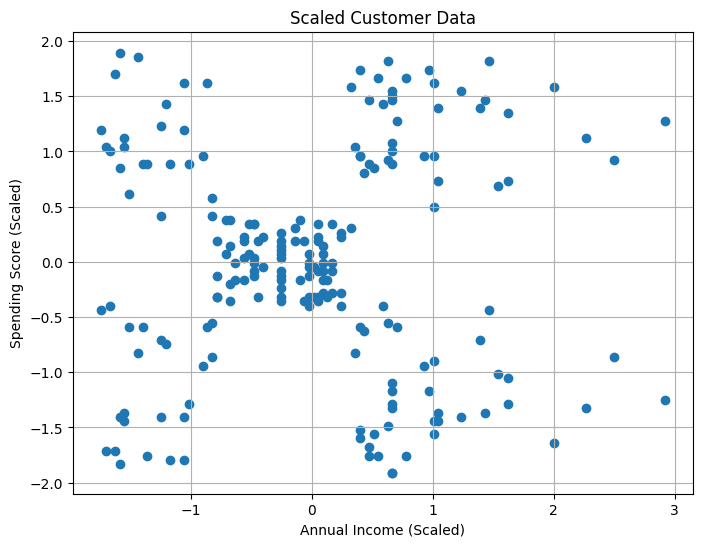

In [13]:
# Visualizing the scaled customer data

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1]
)

plt.title("Scaled Customer Data")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.grid()
plt.show()

In [14]:
# Setting DBSCAN parameters

eps_value = 0.5
min_samples_value = 5

print("Epsilon:", eps_value)
print("Minimum Samples:", min_samples_value)

Epsilon: 0.5
Minimum Samples: 5


In [15]:
# Creating the DBSCAN model

dbscan = DBSCAN(
    eps=eps_value,
    min_samples=min_samples_value
)

print("DBSCAN model created successfully!")

DBSCAN model created successfully!


In [16]:
# Training the DBSCAN model

dbscan.fit(X_scaled)

print("DBSCAN model trained successfully!")

DBSCAN model trained successfully!


In [17]:
# Generating cluster labels

cluster_labels = dbscan.labels_

print("Cluster Labels:")
print(cluster_labels)

Cluster Labels:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]


In [18]:
# Identifying the number of clusters

unique_labels = set(cluster_labels)

n_clusters = len(
    unique_labels - {-1}
)

print("Number of Clusters:", n_clusters)

Number of Clusters: 2


In [19]:
# Counting noise points

noise_count = list(cluster_labels).count(-1)

print("Number of Noise Points:", noise_count)

Number of Noise Points: 8
